#### make_blobs() : 분류용 가상 데이터 생성 함수
- 인수
    - n_samples : 표본 데이터의 수, 디폴트 100
    - n_features : 독립 변수의 수. 디폴트 2
    - centers : 정수 또는 [n_centers, n_features] 크기의 배열. 생성할 클러스터의 수 혹은 중심. 디폴트 3
    - cluster_std: 클러스터의 표준 편차. 디폴트 1.0
    - center_box: 생성할 클러스터의 바운딩 박스(bounding box), 디폴트 (-10.0, 10.0))

- 반환값:
    - X : 독립 변수. [n_samples, n_features] 크기의 배열
    - y : 종속 변수. [n_samples] 크기의 배열

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=50, centers=2, cluster_std=0.5, random_state=4)
print(X)
print(y)

[[ 9.24222414  1.36290933]
 [ 9.17124955  3.52485535]
 [ 8.84264231  1.29144424]
 [ 9.13144602  0.15235637]
 [ 8.66686663  0.93996493]
 [ 8.76869749  1.19960487]
 [10.45227689  1.14179259]
 [ 9.4874227   3.93018752]
 [ 9.55834394  4.10909742]
 [10.03578098  4.41764995]
 [ 9.70226758  0.96771277]
 [ 9.53292197  5.29136138]
 [ 8.90512626  4.03222184]
 [ 8.91604215  5.30752241]
 [ 9.42054325  0.3401709 ]
 [ 9.55313298  1.11077156]
 [ 9.01498386  1.21587064]
 [ 8.84910095  0.97186135]
 [ 9.73389792  0.02420705]
 [ 9.1891148   1.54564628]
 [ 9.27524446  1.34568829]
 [ 9.85130417  4.30586485]
 [ 9.0167434   1.24393257]
 [ 9.70857663  4.44654264]
 [10.69197928  4.47249157]
 [ 9.4779887   4.39064298]
 [ 9.2024951   1.34290093]
 [10.14364725  4.26904052]
 [ 9.00096813  4.51145554]
 [ 9.6022578   3.81543147]
 [ 8.78780476  1.36356316]
 [ 9.9310365   4.5579437 ]
 [10.38453221  1.40206546]
 [ 8.76218865  1.12014356]
 [ 9.88910809  4.20871461]
 [10.08959651  3.97249761]
 [ 8.9815029   4.43675221]
 

In [2]:
y = 2 * y - 1
y

array([-1,  1, -1, -1, -1, -1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1, -1,
       -1, -1, -1, -1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1,  1, -1, -1,
        1,  1,  1, -1, -1, -1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1])

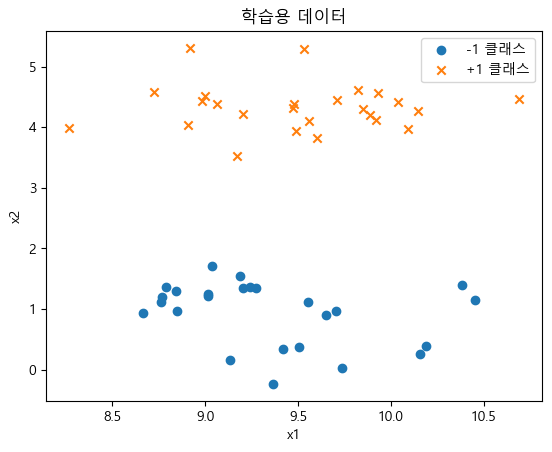

In [3]:
plt.rcParams["font.family"] = 'Malgun Gothic'
plt.scatter(X[y == -1, 0], X[y == -1, 1], marker='o', label="-1 클래스")
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', label="+1 클래스")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("학습용 데이터")
plt.show()

#### 주요 파라미터
- 커널(kernel) : 판별 경계를 찾기위한 내적 함수. 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'. default는 rbf
- C  : 잘못 분류된 데이터로부터 해당 클래스의 결정 경계까지의 거리로 데이터점이 잘못 분류된 정도를 나타냄
    - SVM 모델이 오류를 어느정도 허용할 것인지 파라미터 C를 통해 지정
    - C값이 클수록 하드마진(오류 허용 안 함), 작을수록 소프트마진(오류를 허용함)
- gamma : 결정 경계를 얼마나 유연하게 그을 것인지 정해주는 역할
    - gamma값을 높이면 학습 데이터에 많이 의존해서 결정 경계를 구불구불 긋게 된다.오버피팅을 초래
    - gamma값을 낮추면 학습 데이터에 별로 의존하지 않고 결정 경계를 직선에 가깝게 긋게 된다. 언더피팅 초래

In [4]:
from sklearn.svm import SVC

model = SVC(kernel='linear', C=1e10).fit(X, y)

In [5]:
model.n_support_ # 각 클래스의 서포트 벡터의 개수

array([1, 1])

In [6]:
model.support_  # 각 클래스의 서포트 벡터의 인덱스

array([42,  1])

In [7]:
model.support_vectors_ # 각 클래스의 서포트의 x값

array([[9.03715314, 1.71813465],
       [9.17124955, 3.52485535]])

In [8]:
y[model.support_]

array([-1,  1])

In [9]:
model.coef_ # 기울기((w)

array([[0.08171082, 1.10091404]])

In [10]:
model.intercept_ # 절편(b)

array([-3.62995208])

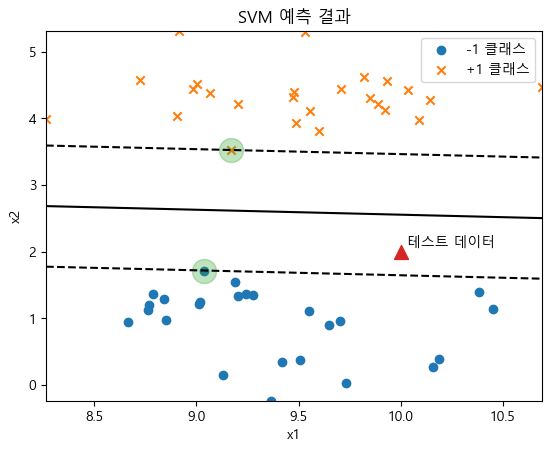

In [11]:
import numpy as np

xmin = X[:, 0].min()
xmax = X[:, 0].max()
ymin = X[:, 1].min()
ymax = X[:, 1].max()
xx = np.linspace(xmin, xmax, 10)
yy = np.linspace(ymin, ymax, 10)
X1, X2 = np.meshgrid(xx, yy)
Z = np.empty(X1.shape)

for (i, j), val in np.ndenumerate(X1):
    x1 = val
    x2 = X2[i, j]
    p = model.decision_function([[x1, x2]])
    Z[i, j] = p[0]

levels = [-1, 0, 1]
linestyles = ['dashed', 'solid', 'dashed']
plt.scatter(X[y == -1, 0], X[y == -1, 1], marker='o', label="-1 클래스")
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', label="+1 클래스")
plt.contour(X1, X2, Z, levels, colors='k', linestyles=linestyles)
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=300, alpha=0.3)

x_new = [10, 2]
plt.scatter(x_new[0], x_new[1], marker='^', s=100)
plt.text(x_new[0] + 0.03, x_new[1] + 0.08, "테스트 데이터")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("SVM 예측 결과")
plt.show()

In [12]:
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Win11Pro\scikit_learn_data


In [13]:
faces.keys()

dict_keys(['data', 'images', 'target', 'DESCR'])

In [14]:
print(faces.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [15]:
faces.data.shape

(400, 4096)

In [16]:
faces.images.shape

(400, 64, 64)

In [17]:
faces.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

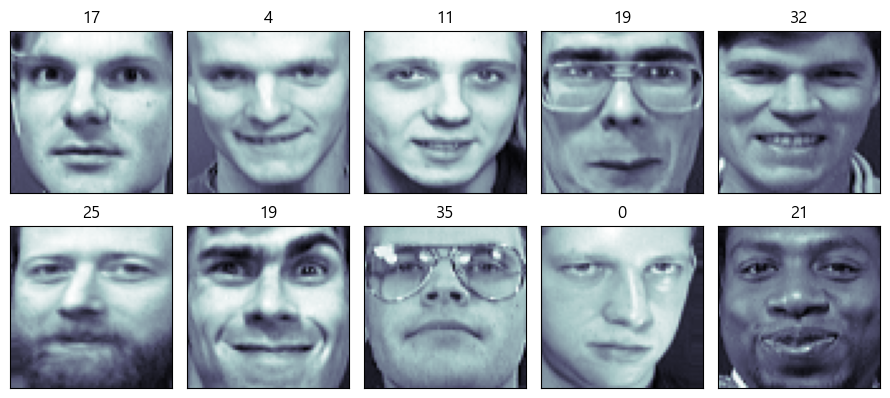

In [18]:
N = 2
M = 5
np.random.seed(0)
fig = plt.figure(figsize=(9, 5))
plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
klist = np.random.choice(range(len(faces.data)), N * M)
for i in range(N):
    for j in range(M):
        k = klist[i * M + j]
        ax = fig.add_subplot(N, M, i * M + j + 1)
        ax.imshow(faces.images[k], cmap=plt.cm.bone)
        ax.grid(False)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
        plt.title(faces.target[k])
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(faces.data, faces.target, test_size=0.4,
                                                    random_state=0)

In [20]:
from sklearn.svm import SVC
svc = SVC(kernel='linear').fit(X_train, y_train)

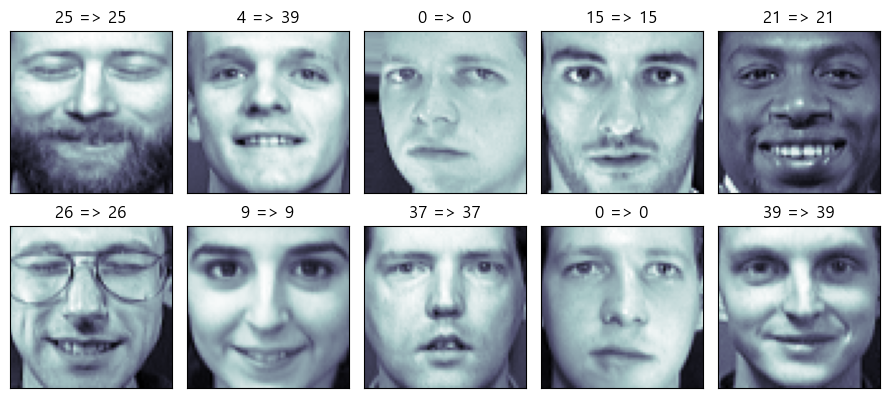

In [22]:
N = 2
M = 5
np.random.seed(0)
fig = plt.figure(figsize=(9, 5))
plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
klist = np.random.choice(range(len(y_test)), N * M) # 수정
for i in range(N):
    for j in range(M):
        k = klist[i * M + j]
        ax = fig.add_subplot(N, M, i * M + j + 1)
        ax.imshow(X_test[k:(k + 1), :].reshape(64, 64), cmap=plt.cm.bone) # 수정
        ax.grid(False)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
        plt.title("%d => %d" % (y_test[k], svc.predict(X_test[k:(k + 1), :])[0])) # 수정
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_test = svc.predict(X_test)
accuracy_score(y_test, y_pred_test)

0.925

In [24]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         4
           3       0.50      1.00      0.67         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         5
           6       0.83      0.83      0.83         6
           7       1.00      0.67      0.80         3
           8       0.67      1.00      0.80         2
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         4
          12       0.67      1.00      0.80         4
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         6
          15       1.00      0.33      0.50         6
          16       0.67      1.00      0.80         2
          17       1.00    

In [25]:
from sklearn.svm import SVR # 비선형 회귀 모델, LinearSVR: 선형 회귀 모델
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
df = pd.read_csv("boston_house.csv")
df.head(2)

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS,Target
0,65.2,396.9,6.575,0.00632,4.0900,2.31,4.98,0.538,15.3,1,18.0,296,0,24.0
1,78.9,396.9,6.421,0.02731,4.9671,7.07,9.14,0.469,17.8,2,0.0,242,0,21.6


In [27]:
x = df.drop('Target', axis=1)
y = df['Target']

In [28]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=0)

In [29]:
xtrain.shape, xtest.shape

((354, 13), (152, 13))

In [30]:
svr = SVR(kernel='linear', gamma='auto')
svr.fit(xtrain, ytrain)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [31]:
print('가중치 :', svr.coef_)
print('절편항 :', svr.intercept_)

가중치 : [[-0.03685891  0.01107594  5.38721804 -0.14394647 -0.95162094 -0.00727968
  -0.31328718 -1.72804778 -0.70684295  0.12299068  0.03672556 -0.00925134
   1.73782643]]
절편항 : [10.56898773]


In [32]:
score = svr.score(xtrain, ytrain)
print("R-squared: ", score)

R-squared:  0.7364554038963336


In [33]:
ypred = svr.predict(xtest)

mse = mean_squared_error(ytest, ypred)
print("MSE: ", mse)

MSE:  31.89389399349386


In [34]:
from sklearn.metrics import r2_score

r2_score(ytest, ypred)

0.6169614862878827